<a href="https://colab.research.google.com/github/hnur79997-stack/Uts_VisiKomputer/blob/main/Uts_segmentasi_citra_visikomputer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

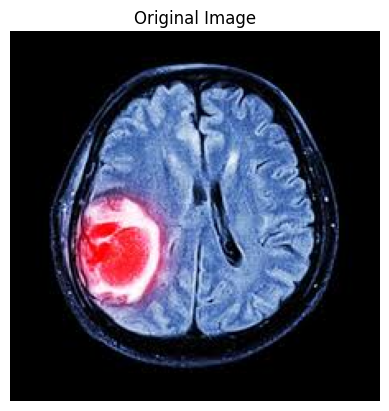

In [37]:
img = cv2.imread("tumor otak.jpg")  # ganti bisa pakai "tumor otak.jpg"
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

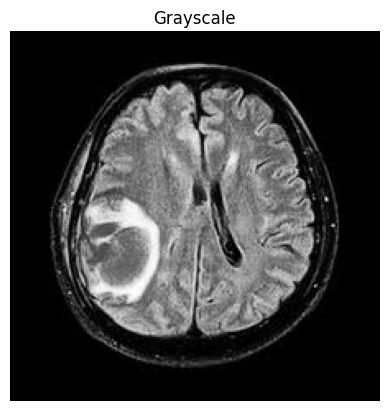

In [38]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

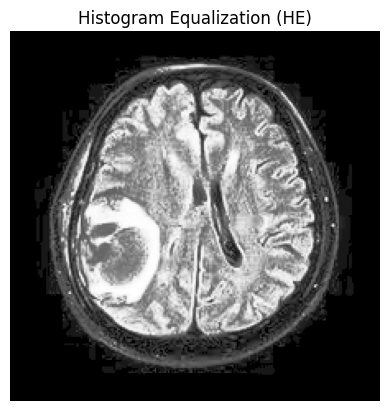

In [39]:
he = cv2.equalizeHist(gray)

plt.imshow(he, cmap='gray')
plt.title("Histogram Equalization (HE)")
plt.axis('off')

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

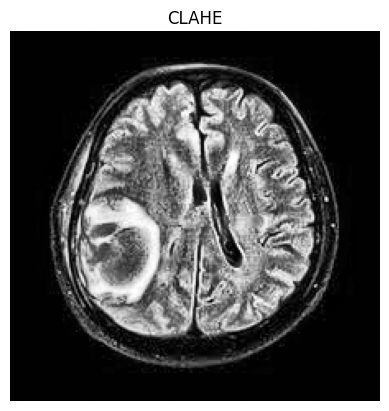

In [40]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(gray)

plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

Text(0.5, 1.0, 'Threshold CLAHE')

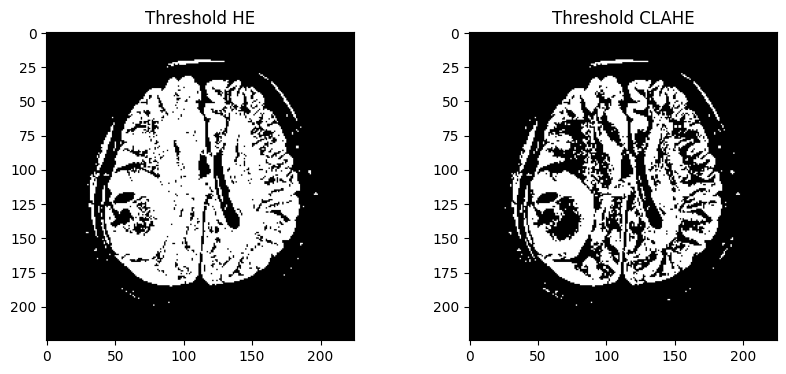

In [41]:
_, thresh_he = cv2.threshold(he, 128, 255, cv2.THRESH_BINARY)
_, thresh_clahe = cv2.threshold(clahe_img, 128, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(thresh_he, cmap='gray')
plt.title("Threshold HE")

plt.subplot(1,2,2)
plt.imshow(thresh_clahe, cmap='gray')
plt.title("Threshold CLAHE")

Text(0.5, 1.0, 'Morphology CLAHE')

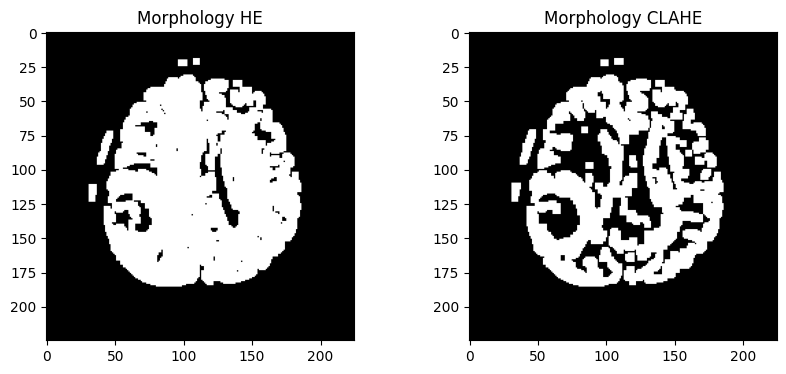

In [42]:
kernel = np.ones((3,3), np.uint8)

# Opening
opening_he = cv2.morphologyEx(thresh_he, cv2.MORPH_OPEN, kernel)
opening_clahe = cv2.morphologyEx(thresh_clahe, cv2.MORPH_OPEN, kernel)

# Dilation
dilate_he = cv2.dilate(opening_he, kernel, iterations=1)
dilate_clahe = cv2.dilate(opening_clahe, kernel, iterations=1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(dilate_he, cmap='gray')
plt.title("Morphology HE")

plt.subplot(1,2,2)
plt.imshow(dilate_clahe, cmap='gray')
plt.title("Morphology CLAHE")

In [43]:
def watershed_segmentation(original, binary):
    kernel = np.ones((3,3), np.uint8)

    # noise removal
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # background
    sure_bg = cv2.dilate(opening, kernel, iterations=2)

    # foreground
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)

    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # marker labeling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    original_copy = original.copy()
    markers = cv2.watershed(original_copy, markers)

    original_copy[markers == -1] = [255,0,0]  # garis merah

    return original_copy

Text(0.5, 1.0, 'Watershed CLAHE')

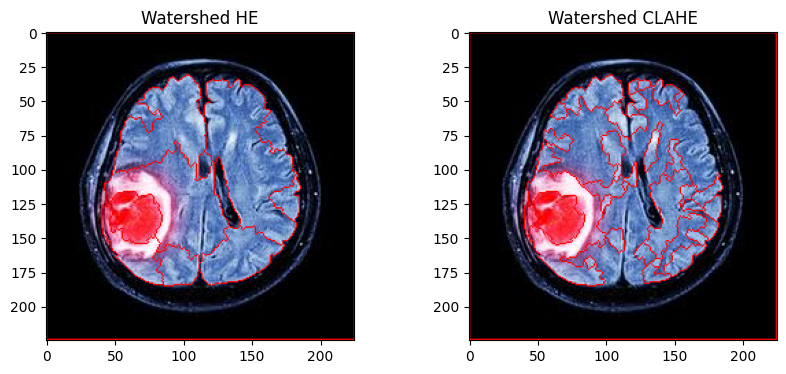

In [44]:
ws_he = watershed_segmentation(img.copy(), dilate_he)
ws_clahe = watershed_segmentation(img.copy(), dilate_clahe)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(ws_he)
plt.title("Watershed HE")

plt.subplot(1,2,2)
plt.imshow(ws_clahe)
plt.title("Watershed CLAHE")

In [45]:
def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

# hitung
mse_he = mse(gray, he)
mse_clahe = mse(gray, clahe_img)

ssim_he = ssim(gray, he)
ssim_clahe = ssim(gray, clahe_img)

print("=== HASIL EVALUASI ===")
print("HE -> MSE:", mse_he, " SSIM:", ssim_he)
print("CLAHE -> MSE:", mse_clahe, " SSIM:", ssim_clahe)

=== HASIL EVALUASI ===
HE -> MSE: 69.14287407407407  SSIM: 0.783946664917998
CLAHE -> MSE: 55.09839012345679  SSIM: 0.6773714519505697


Text(0.5, 1.0, 'Tumor')

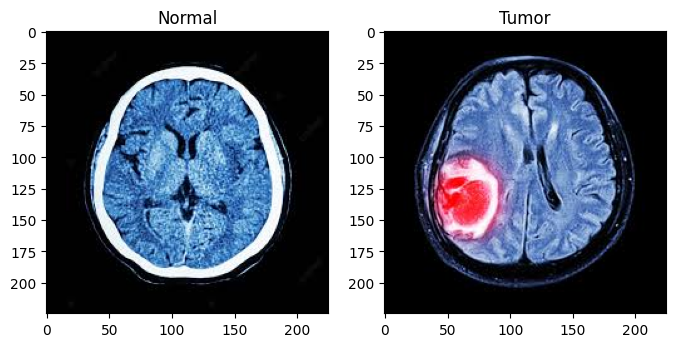

In [46]:
img1 = cv2.imread("Otak Normal.jpg")
img2 = cv2.imread("tumor otak.jpg")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Normal")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Tumor")